# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 15. Линейная регрессия

Импортируем все необходимое:
    
* библиотеку `pandas`;
* библиотеку `seaborn`;
* функцию `LinearRegression()` из модуля `linear_model` внутри `sklearn`;
* функцию `train_test_split()` из модуля `model_selection` внутри `sklearn`;
* функции для разных метрик из модуля `metrics` внутри `sklearn`.

In [1]:
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Так как далее будем строить графики с помощью библиотеки `seaborn`, для красоты установим светлую тему графиков:

In [2]:
sns.set_theme(style = "whitegrid")

Загрузим данные из файла `50_Startups.csv` по стартапам:

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyDat25/refs/heads/main/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Переменные в файле:

* `R&D Spend`: расходы на «исследования и развитие» (Research and Development);
* `Administration`: расходы на административную деятельность;
* `Marketing Spend`: расходы на маркетинг;
* `State`: штат;
* `Profit`: прибыль стартапа.

## Часть 1. Диаграммы рассеивания и регрессии

В библиотеке `seaborn` есть две функции для визуализации парных регрессионных моделей:

* функция `lmplot()` – строит диаграмму рассеивания с добавленной на нее регрессионной прямой (линейная модель);
* функция `regplot()` – строит диаграмму рассеивания с добавленным на нее графиком функции (необязательно линейная модель).

Функцию `regplot()` удобно использовать, если мы захотим проверить, насколько разумно использовать нелинейную модель, например, с подгонкой с помощью квадратичной или кубической функции (многочлен второй степени или многочлен третьей степени).

### Задача 1

Постройте график для линейной регрессии `Profit` на `Marketing Spend` с помощью `lmplot()`. Что означает закрашенная область вокруг регрессионной прямой?

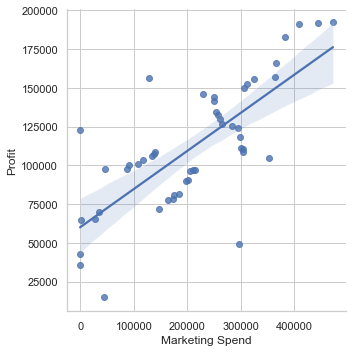

In [4]:
sns.lmplot(data = df, x = "Marketing Spend", y = "Profit");

Закрашенная область вокруг прямой – 95%-ный доверительный интервал для регрессионной прямой (для функции регрессии), его ещё иногда называют доверительной трубкой. Он показывает, в какой области может с 95%-ной уверенностью лежать регрессионная прямая, если мы будем независимым образом повторять построение модели на немного других выборках такого же размера. Можем увеличить уровень доверия до 99% и убедиться, что, как и всегда, с увеличением уровня доверия доверительный интервал становится шире:

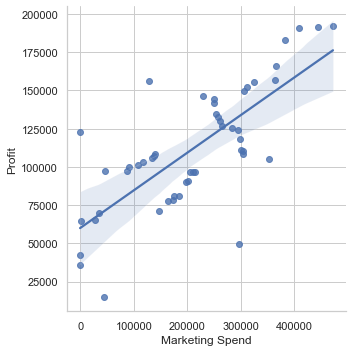

In [5]:
# обратите внимание: уровень доверия – в процентах, не в долях
sns.lmplot(data = df, x = "Marketing Spend", y = "Profit", ci = 99);

Если доверительный интервал для регрессионной функции нам не нужен, можем в `ci` выставить уровень доверия 0 (или вообще указать значение `None`):

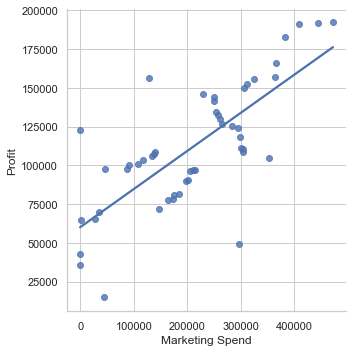

In [6]:
sns.lmplot(data = df, x = "Marketing Spend", y = "Profit", ci = 0);

### Задача 2

Добавьте группировку и постройте диаграммы рассеивания с регрессионными прямыми по группам – стартапы можно разделить по штатам. Проинтерпретируйте полученные результаты.

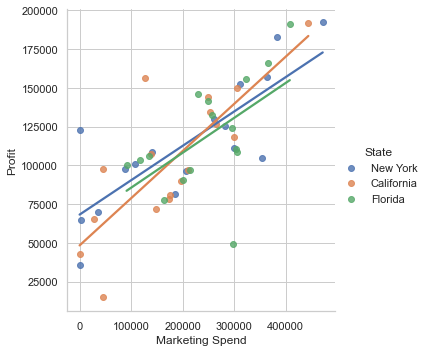

In [7]:
# hue – цвет зависит от значений в этом столбце

sns.lmplot(data = df, x = "Marketing Spend", y = "Profit", ci = 0,
           hue = "State");

Видно, что средняя прибыль у стартапов в разных штатах немного отличается (при нулевых расходах на маркетинг), а сила связи между показателями в трех штатах примерно одинакова. Прямые для Нью-Йорка и Флориды параллельны, а для Калифорнии наклон чуть более сильный.

Можно развести графики по разным ячейкам, одна ячейка для каждой группы (вернем 95%-ные доверительные интервалы):

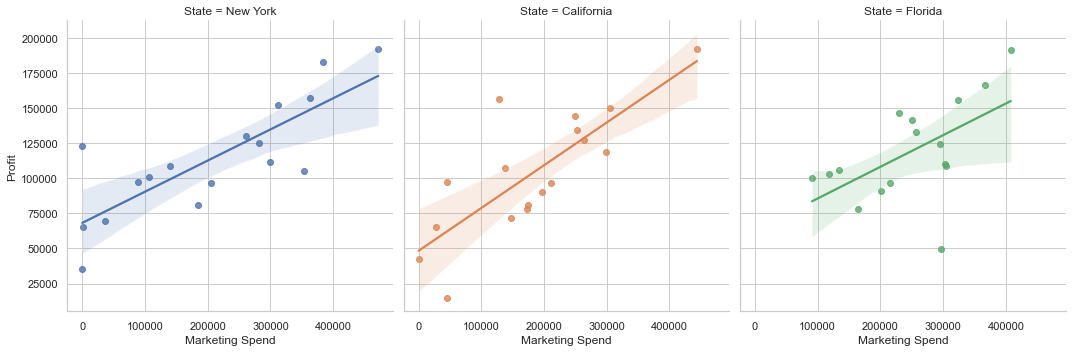

In [8]:
# hue – цвет зависит от значений в этом столбце
# col – разделение по столбцам (columns)

sns.lmplot(data = df, x = "Marketing Spend", y = "Profit", 
           hue = "State", col = "State");

Если `hue` убрать и оставить, деление на отдельные графики останется, а вот цвет у всех точек и прямых будет одинаковым:

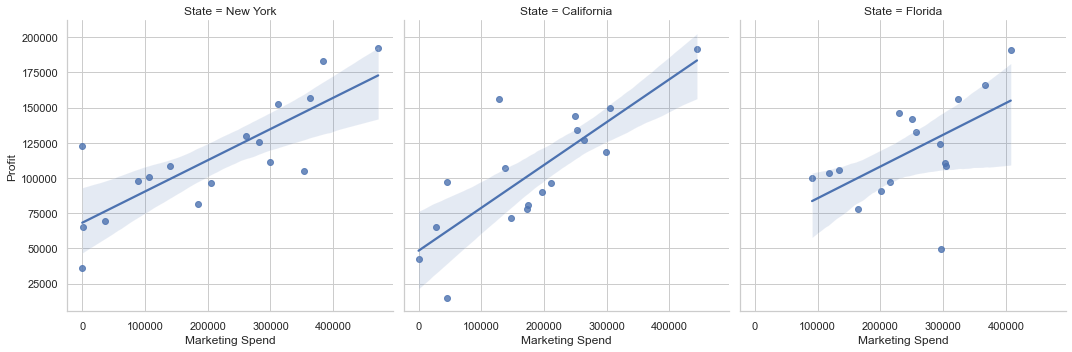

In [9]:
sns.lmplot(data = df, x = "Marketing Spend", y = "Profit", 
           col = "State");

**NB.** Так как данные учебные (50 стартапов – 50 наблюдений), при разбиении по штатам мы получаем совсем маленькое количество наблюдений в каждой группе. Не самые лучшие условия для построения даже простых регрессий, однако такие данные были выбраны специально – чтобы в третьей части практикума деление на тренировочную и тестовую выборку было более наглядным за счет маленького объема исходной выборки.

### Задача 3

Постройте графики для регрессий `Profit` на `Marketing Spend` с помощью `regplot()`, используя для подгонки квадратичную и кубическую функцию.

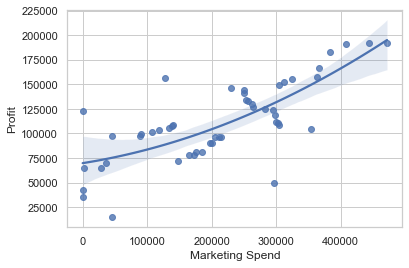

In [10]:
# f(x) = ax^2 + bx + c
# степень/порядок многочлена 2 (order = 2)

sns.regplot(data = df, x = "Marketing Spend", y = "Profit", order = 2);

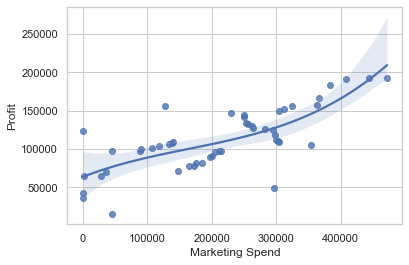

In [11]:
# f(x) = ax^3 + bx^2 + cx + d
# степень/порядок многочлена 3 (order = 3)

sns.regplot(data = df, x = "Marketing Spend", y = "Profit", order = 3);

## Часть 2. Парная и множественная линейная регрессия: оценка коэффициентов

Все функции для регрессий разного вида в `sklearn` устроены по одинаковой схеме. Так как зависимая переменная в моделях всегда одна, она должна быть представлена в **одномерном виде** (список/массив или один столбец датафрейма), а вот независимых переменных может быть несколько, поэтому они должны быть представлены в **двумерном виде** (список списков, массив массивов, матрица, датафрейм). 

В официальной [документации](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares) `sklearn` в примерах приводится вариант модели на списках. Рассмотрим аналог примеров данных из документации:

    X = [[0, 3], [1, 4], [2, 5]]
    y = [10, 20, 30]
    
В данном случае `X` – это матрица, список списков, который «имитирует» таблицу с двумя столбцами:

<table>
    <tr><th>x1</th><th>x2</th></tr>
    <tr><td>0</td><td>3</td></tr>
    <tr><td>1</td><td>4</td></tr>
    <tr><td>2</td><td>5</td></tr>
</table>

А `y` – это просто перечень значений, уже извлеченных из таблицы.

### Задача 4

Мы начнем с парной модели – регрессии `Profit` на `Marketing Spend`. Другими словами:

* прибыль стартапа `Profit` – зависимая/целевая переменная, отклик, target/output variable;
* расходы на маркетинг `Marketing Spend` – независимая переменная/признак, предиктор, feature/input variable.

Выберите нужные столбцы, сохраните их как `y` и `X`. Запустите оценку модели:

* зарезервируйте место под модель – создайте объект соответствующего класса `LinearRegression`;
* примените к созданному объекту метод `.fit()` для подгонки/оценки модели и сохраните результаты как `model`.

Извлеките коэффициенты модели (атрибуты `.intercept_` и `.coef_`) и запишите уравнение модели.

In [12]:
y = df["Profit"]
X = df[["Marketing Spend"]]

**NB.** В силу описанной выше логики работы функций `sklearn`, даже если независимая переменная одна, столбец из датафрейма нужно выбирать списком (не просто `df["Marketing Spend"]`, а с квадратными скобками внутри), чтобы у `X` была двумерная структура. Сравним: 

In [13]:
print(type(y)) # Series ≈ одномерный массив
print(type(X)) # DataFrame = таблица = матрица = двумерный массив

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [14]:
model = LinearRegression().fit(X, y)

print(model.intercept_)
print(model.coef_)

60003.54881577173
[0.24645926]


Итого получаем уравнение: 

$$
\widehat{\text{Profit}} = 60003.55 + 0.25 \times \text{Marketing Spend}
$$

При увеличении расходов на маркетинг на один доллар, прибыль стартапа, в среднем, возрастает на 0.25 доллара. Если на маркетинг стартаперы не тратят ничего (что маловероятно), то средняя прибыль стартапа, согласно модели, составит примерно 60 тысяч долларов.

**NB.** Коэффициенты модели (углы наклона) в `.coef_` всегда будут представлены в виде массива, потому что теоретически модель может быть множественной, и тогда коэффициентов будет несколько.

## Часть 3: разбиение на тренировочную и тестовую выборку и метрики качества

### Задача 5

Представьте, что нам нужно построить следующую линейную модель:

$$
\widehat{\text{Profit}} = b_0 + b_1 \times \text{Marketing Spend} + b_2 \times \text{R&D Spend}
$$

a. Используя [функцию](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) `train_test_split()`, разделите данные на тренировочную и тестовую выборку в соотношении 80 на 20 (воспроизводимость `random_state` равна 42).

b. Обучите модель на тренировочной выборке. Укажите чему, согласно модели, равна прибыль стартапа, если расходы на маркетинг равны среднему значению по этой выборке, а расходы на исследования и развитие равны медианному значению по этой выборке.

c. На тестовой выборке рассчитайте все основные метрики качества модели: среднюю квадратичную ошибку, среднюю абсолютную ошибку и $R^2$.

In [15]:
y = df["Profit"]
X = df[["Marketing Spend", "R&D Spend"]]

In [16]:
# 80% наблюдений в тренировочной выборке (X_train и y_train)
# 20% наблюдений в тестовой выборке (X_test и y_test),
# отсюда test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

Функция возвращает четыре объекта:
    
* датафрейм со значениями независимых переменных для 80% наблюдений –  `X_train`;
* датафрейм со значениями независимых переменных для 20% наблюдений –  `X_test`;
* столбец со значениями зависимой переменной для 80% наблюдений – `y_train`;
* столбец со значениями зависимой переменной для 20% наблюдений – `y_test`.

Тренировочная выборка – это 80% строк из исходного датафрейма `df`, здесь представлена двумя частями: `X_train` и `y_train`. Тестовая выборка – оставшиеся 20% из исходного датафрейма `df`, здесь представлена: `y_train` и `y_test`.

Всего в `df` 50 наблюдений, можем ожидать, что в тренировочной выборке будет 40 наблюдений (80% от 50), а в тестовой – 10 наблюдений (20% от 50). Проверим:

In [17]:
# pandas DataFrame, 40 строк и 2 столбца
print(X_train.shape)
X_train.head()

(40, 2)


,Marketing Spend,R&D Spend
12,249839.44,93863.75
4,366168.42,142107.34
37,197029.42,44069.95
8,311613.29,120542.52
3,383199.62,144372.41


In [18]:
# pandas DataFrame, 10 строк и 2 столбца
print(X_test.shape)
X_test.head()

(10, 2)


,Marketing Spend,R&D Spend
13,252664.93,91992.39
39,174999.30,38558.51
30,91131.24,61994.48
45,1903.93,1000.23
17,282574.31,94657.16


In [19]:
# pandas Series, 40 строк и 1 столбец
print(y_train.shape)
y_train.head()

(40,)


12    141585.52
4     166187.94
37     89949.14
8     152211.77
3     182901.99
Name: Profit, dtype: float64

In [20]:
# pandas Series, 10 строк и 1 столбец
print(y_test.shape)
y_test.head()

(10,)


13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
Name: Profit, dtype: float64

Обучаем модель (получаем оценки коэффициентов при независимых переменных + константы) на тренировочной выборке – на вход `.fit()` подаем уже не `X` и `y`, а `X_train` и `y_train`:

In [21]:
mod = LinearRegression().fit(X_train, y_train)
print(mod.intercept_)
print(mod.coef_)

45542.39247751424
[0.03923979 0.78337431]


Запишем уравнение модели:

$$
\widehat{\text{Profit}} = 45542.39 + 0.04 \times \text{Marketing Spend} + 0.78 \times \text{R&D Spend}
$$

* При увеличении расходов на маркетинг на один доллар, прибыль стартапа, в среднем, при прочих равных условиях, возрастает на 0.04 доллара. 

* При увеличении расходов на Research & Development на один доллар, прибыль стартапа, в среднем, при прочих равных условиях, возрастает на 0.78 доллара.

Чтобы найти предсказанное значение `Profit` для значений из пункта (b), нужно подставить среднее по `Marketing Spend` и медиану для `R&D Spend` в уравнение выше. Чтобы сделать это автоматически, воспользуемся методом `.predict()`:

In [22]:
# считаем значения для подстановки в уравнение

x1 = X_train["Marketing Spend"].mean()
x2 = X_train["R&D Spend"].median()
print(x1, x2)

235747.08099999995 75124.20999999999


In [23]:
# подставляем

mod.predict([[x1, x2]])

/opt/anaconda3/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


array([113643.43429656])

Итак, если расходы на маркетинг равны среднему значению по тренировочной выборке, а расходы на исследование и развитие равны медианному значению по той же выборке, согласно модели, прибыль стартапа составляет 113643.43 доллара.

**NB.** Так как метод `.predict()` по умолчанию работает с матрицами/датафреймами, то есть двумерными структурами, значения выше мы представили в виде списка списков:

`[[x1, x2]]` – таблица из одной строки `[x1, x2]`. 

Для вычисления метрик для сравнения нужно иметь наблюдаемые (реальные) значения зависимой переменной и предсказанные значения зависимой переменной. Как мы помним, в основе многих метрик лежат ошибки/остатки модели:

$$
\varepsilon = y - \hat{y}
$$

Предскажем значения зависимой переменной на основе тестовой выборки `X_test`:

In [24]:
# это Profit^, 
# в тестовой выборке всего 10 наблюдений

y_pred = mod.predict(X_test)
print(y_pred)

[127521.38604123  82615.07411457  97683.2462344   46400.65677644
 130782.53611917  45967.0205249  109813.19061887 101612.68921418
  97023.64013854 113241.36575804]


По идее, мы и сами можем здесь вычислить некоторые метрики – вычислить разность между `y_test` и `y_pred`, а затем взять модуль от всех полученных значений и усреднить (это будет MAE, средняя абсолютная ошибка) или возвести все полученные значения в квадрат и усреднить (это будет MSE, средняя квадратичная ошибка):

In [25]:
print("MAE: ", (y_test - y_pred).abs().mean())
print("MSE: ", ((y_test - y_pred) ** 2).mean())

MAE:  6469.181721468598
MSE:  67343832.58979627


Однако мы можем поступить проще – вызвать функции, импортированные в самом начале практикума и подставить туда для вычислений `y_test` и `y_pred`:

In [26]:
print("MSE", mean_squared_error(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("R2", r2_score(y_test, y_pred))

MSE 67343832.58979627
MAE 6469.181721468598
R2 0.9168381183550245
